# Упоминания Сталина, Ленина и Трампа: дни, недели и месяцы

Период: **01.01.2023–02.10.2026**, календарные даты Москвы. Пять источников выбираются
по сумме найденных кандидатов на упоминания трёх фамилий. ТВ-канал и сайт того же
медиа считаются разными источниками. Есть также отдельный рейтинг веб-медиа и ТВ.

По умолчанию всё работает **локально**, без авторизации и запросов в BigQuery.
Откройте тетрадку в Jupyter / VS Code и выберите **Run All / Выполнить все ячейки**.
Если библиотек нет, выполните следующую ячейку установки, убрав `#` перед `%pip`.
Для переноса нужны эта тетрадка, `data/visualization/web_daily.jsonl.gz` и
`data/bigquery_upload/tv_daily_coverage.jsonl.gz` с сохранением структуры папок.

Это **кандидаты по фамилии**, а не подтверждённые упоминания конкретных людей:
пока не исключены улицы Ленина, однофамильцы, родственники и ошибки распознавания.
ТВ включает все архивные передачи; фильтр только новостных программ ещё не применён.


In [1]:
# При необходимости раскомментируйте и выполните один раз:
# %pip install pandas numpy matplotlib ipykernel
# Для необязательного обновления из облака:
# %pip install google-cloud-bigquery


## 1. Настройки

Даты и размер пятёрки можно изменить здесь. `TOP_SCOPE='all'` выбирает среди всех
источников; `'web'` — только сайты; `'tv'` — только ТВ (в архиве всего четыре канала).
Для прогноза пятёрку лучше выбирать только на обучающем периоде: задайте `RANK_END`.
Графики ниже описательные, поэтому по умолчанию рейтинг рассчитан на всём периоде.


In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown

ROOT_OVERRIDE = None  # Например: Path('data_collection')
if ROOT_OVERRIDE is not None:
    ROOT = Path(ROOT_OVERRIDE).expanduser().resolve()
else:
    candidates = []
    for parent in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend([parent, parent / 'data_collection'])
    ROOT = next((p for p in candidates if (p/'data/bigquery_upload/tv_daily_coverage.jsonl.gz').exists()), None)
    if ROOT is None:
        raise FileNotFoundError('Укажите ROOT_OVERRIDE: папку data_collection с сохранёнными данными.')

START = pd.Timestamp('2023-01-01')
END = pd.Timestamp('2026-10-02')  # Включительно, MSK
RANK_END = END
TOP_N = 5
TOP_SCOPE = 'all'
REFRESH_WEB = False  # True только для явного обновления уже собранных таблиц BigQuery
PROJECT = 'forecasting-mentions-second'

PEOPLE = {'stalin':'Сталин', 'lenin':'Ленин', 'trump':'Трамп'}
COLORS = {'stalin':'#b33c4a', 'lenin':'#346aa0', 'trump':'#24856e'}
COLS = [f'{p}_candidates' for p in PEOPLE]
TV_NAMES = {'1TV':'Первый канал', 'NTV':'НТВ', 'RUSSIA1':'Россия 1', 'RUSSIA24':'Россия 24'}
PERIODS = {'day':('D','По дням'), 'week':('W-MON','По неделям'), 'month':('MS','По месяцам')}
CACHE = ROOT/'data/visualization/web_daily.jsonl.gz'
OUT = ROOT/'output/mentions_visualization'
FIGURES = OUT/'figures'
TABLES = OUT/'tables'
for folder in (FIGURES, TABLES): folder.mkdir(parents=True, exist_ok=True)
assert START <= RANK_END <= END and TOP_SCOPE in {'all','web','tv'}
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':10,
                     'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.titleweight':'bold', 'figure.facecolor':'white'})
print(f'Данные: {ROOT}')
print(f'Период: {START:%d.%m.%Y} — {END:%d.%m.%Y}')


Данные: C:\Users\user\Documents\afgan\forecasting_mentions
Период: 01.01.2023 — 02.10.2026


## 2. Правило подсчёта веб-упоминаний и необязательное обновление

Для URL берём **самый ранний доступный снимок, содержащий кандидатов** в нашем
сохранённом периоде; считаем все строки этого снимка. Последующие снимки того же URL
не суммируем. Это не обязательно первая опубликованная версия статьи. Повторы с
одинаковым временем обработки полностью отделить от реальных повторов нельзя:
полные веб-контексты не были сохранены. Веб-дата — дата обнаружения GDELT, ТВ-дата — дата передачи.

`pos` — дециль статьи, **не уникальная позиция слова**, поэтому удаление строк по
`URL + фамилия + pos` занижает реальные повторы. Описание: [GDELT Web NGrams 3.0](https://blog.gdeltproject.org/announcing-the-new-web-news-ngrams-3-0-dataset/).
Одинаковый фильтр начальной пунктуации применяется ко всем неделям; поддерживаются
варианты без начальной пунктуации, с `«` или `"`. Другие варианты отсутствуют в основной выгрузке.

SQL ниже читает только уже собранные таблицы нашего проекта. При `REFRESH_WEB=False`
ячейка не делает облачных запросов. Для обновления нужны существующая Google-авторизация
и пакет `google-cloud-bigquery`; лимит одного запроса — 2 GiB чтения.


In [3]:
WEB_SQL = '-- Read only the collected tables, never the original GDELT corpus.\n-- One earliest observed candidate-containing snapshot per URL; retain every occurrence.\n-- pos is an article decile, NOT a unique token position: never deduplicate by pos.\n-- Keep the same leading punctuation filter for every week of the collection.\nWITH base AS (\n  SELECT seen_at, DATE(seen_at, \'Europe/Moscow\') AS day,\n    NET.REG_DOMAIN(url) AS source, url, person\n  FROM `forecasting-mentions-second.forecasting_mentions.web_mentions_candidates_2023_2026`\n  WHERE seen_at >= TIMESTAMP(\'2023-01-01\', \'Europe/Moscow\')\n    AND seen_at < TIMESTAMP(\'2026-10-03\', \'Europe/Moscow\')\n    AND NET.REG_DOMAIN(url) IN (\n      \'ria.ru\',\'tass.ru\',\'rg.ru\',\'rbc.ru\',\'kommersant.ru\',\'interfax.ru\',\n      \'iz.ru\',\'lenta.ru\',\'gazeta.ru\',\'vedomosti.ru\',\'aif.ru\',\'mk.ru\',\n      \'fontanka.ru\',\'1tv.ru\',\'ntv.ru\',\'vesti.ru\',\'ren.tv\',\'tvc.ru\')\n    AND REGEXP_CONTAINS(ngram, r\'^[«"]?[СсЛлТт]\')\n), snapshots AS (\n  SELECT * FROM base\n  QUALIFY seen_at = MIN(seen_at) OVER (PARTITION BY url)\n), mentions AS (\n  SELECT day, source,\n    COUNTIF(person=\'stalin\') AS stalin_candidates,\n    COUNTIF(person=\'lenin\') AS lenin_candidates,\n    COUNTIF(person=\'trump\') AS trump_candidates,\n    COUNT(DISTINCT url) AS candidate_articles\n  FROM snapshots GROUP BY day, source\n), raw AS (\n  SELECT day, source, COUNT(*) AS raw_candidate_rows\n  FROM base GROUP BY day, source\n), catalog AS (\n  SELECT day, source_domain AS source, COUNT(DISTINCT url) AS catalog_articles\n  FROM `forecasting-mentions-second.forecasting_mentions.web_articles`\n  WHERE day >= \'2023-01-01\' AND day < \'2026-10-03\'\n  GROUP BY day, source\n), keys AS (\n  SELECT day, source FROM mentions UNION DISTINCT\n  SELECT day, source FROM raw UNION DISTINCT\n  SELECT day, source FROM catalog\n)\nSELECT k.day, k.source,\n  COALESCE(m.stalin_candidates,0) AS stalin_candidates,\n  COALESCE(m.lenin_candidates,0) AS lenin_candidates,\n  COALESCE(m.trump_candidates,0) AS trump_candidates,\n  COALESCE(m.candidate_articles,0) AS candidate_articles,\n  COALESCE(r.raw_candidate_rows,0) AS raw_candidate_rows,\n  COALESCE(c.catalog_articles,0) AS catalog_articles\nFROM keys k\nLEFT JOIN mentions m USING(day,source)\nLEFT JOIN raw r USING(day,source)\nLEFT JOIN catalog c USING(day,source)\nORDER BY k.day,k.source;\n'

if REFRESH_WEB:
    from google.cloud import bigquery
    client = bigquery.Client(project=PROJECT, location='US')
    query = WEB_SQL.replace('forecasting-mentions-second', PROJECT)
    estimate = client.query(query, job_config=bigquery.QueryJobConfig(dry_run=True, use_query_cache=False))
    limit = 2 * 1024**3
    print(f'Оценка чтения: {estimate.total_bytes_processed / 1024**3:.3f} GiB')
    if estimate.total_bytes_processed > limit:
        raise RuntimeError('Запрос превышает установленный лимит чтения 2 GiB.')
    result = client.query(query, job_config=bigquery.QueryJobConfig(maximum_bytes_billed=limit)).result()
    refreshed = pd.DataFrame([dict(row.items()) for row in result])
    refreshed['day'] = refreshed['day'].astype(str)
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    refreshed.to_json(CACHE, orient='records', lines=True, force_ascii=False, compression='gzip')
    print(f'Обновлено строк: {len(refreshed):,}')


## 3. Загрузка и покрытие

Отсутствующий день не заменяется нулём. Для ТВ ноль возможен при наличии расшифровок;
неполный день показывает только найденные упоминания. Для веб день наблюдаем, если
есть записи кандидатов или статьи в GAL-каталоге. Ноль означает отсутствие кандидатов
**в сохранённой выборке**. GAL служит косвенным признаком наблюдения медиа и не
гарантирует полноту NGrams. Границы доступного периода не доказывают непрерывное покрытие.


In [4]:
if not CACHE.exists():
    raise FileNotFoundError(f'Нет веб-сводки: {CACHE}. Восстановите файл или включите REFRESH_WEB.')
web = pd.read_json(CACHE, lines=True)
tv = pd.read_json(ROOT/'data/bigquery_upload/tv_daily_coverage.jsonl.gz', lines=True)
for frame in (web,tv): frame['day'] = pd.to_datetime(frame['day']).dt.normalize()
assert not web.duplicated(['source','day']).any()
assert not tv.duplicated(['channel','day']).any()
assert (web[COLS].fillna(0) >= 0).all().all()
assert (tv[COLS].fillna(0) >= 0).all().all()

# Полный календарь необходим и для пустых дней, и для правильных сумм по периодам.
def calendar_panel(frame, sources, kind):
    index = pd.MultiIndex.from_product([sources,pd.date_range(START,END)],names=['source','day'])
    result = frame.set_index(['source','day']).reindex(index).reset_index()
    result['kind'] = kind
    result['observed'] = result['observed'].fillna(False).astype(bool)
    result['complete_day'] = result['complete_day'].fillna(False).astype(bool)
    result.loc[~result['observed'], COLS] = np.nan
    return result

web['source'] = 'Веб: ' + web['source']
web['observed'] = (web['catalog_articles'] > 0) | (web['raw_candidate_rows'] > 0)
web['complete_day'] = web['observed']  # Только косвенный признак, не доказанная полнота!
web_panel = calendar_panel(web, sorted(web['source'].unique()), 'web')
tv['source'] = 'ТВ: ' + tv['channel'].map(TV_NAMES)
tv['observed'] = tv['available_transcripts'] > 0
tv['complete_day'] = (tv['coverage_status'] == 'observed_listed_broadcasts') & (tv['inventory_status'].astype(str) == '200')
tv_panel = calendar_panel(tv, ['ТВ: '+TV_NAMES[c] for c in TV_NAMES], 'tv')
daily = pd.concat([tv_panel,web_panel], ignore_index=True)
coverage = daily.groupby(['kind','source']).agg(
    days_in_scope=('day','size'), observed_days=('observed','sum'),
    complete_or_proxy_days=('complete_day','sum'))
coverage['observed_share'] = coverage['observed_days']/coverage['days_in_scope']
display(coverage.round(3))


days_in_scope  observed_days  complete_or_proxy_days  \
kind source                                                                     
tv   ТВ: НТВ                      1371           1350                    1347   
     ТВ: Первый канал             1371           1337                    1335   
     ТВ: Россия 1                 1371           1332                    1327   
     ТВ: Россия 24                1371           1349                    1344   
web  Веб: 1tv.ru                  1371           1341                    1341   
     Веб: aif.ru                  1371           1357                    1357   
     Веб: fontanka.ru             1371           1330                    1330   
     Веб: gazeta.ru               1371            684                     684   
     Веб: interfax.ru             1371           1328                    1328   
     Веб: iz.ru                   1371           1275                    1275   
     Веб: kommersant.ru           1371           1363                    1363   
     Веб: lenta.ru                1371           1269                    1269   
     Веб: mk.ru                   1371           1354                    1354   
     Веб: rbc.ru                  1371           1354                    1354   
     Веб: ren.tv                  1371             65                      65   
     Веб: rg.ru                   1371           1162                    1162   
     Веб: ria.ru                  1371           1358                    1358   
     Веб: tass.ru                 1371           1150                    1150   
     Веб: tvc.ru                  1371            640                     640   
     Веб: vedomosti.ru            1371           1354                    1354   
     Веб: vesti.ru                1371           1333                    1333   

                         observed_share  
kind source                              
tv   ТВ: НТВ                      0.985  
     ТВ: Первый канал             0.975  
     ТВ: Россия 1                 0.972  
     ТВ: Россия 24                0.984  
web  Веб: 1tv.ru                  0.978  
     Веб: aif.ru                  0.990  
     Веб: fontanka.ru             0.970  
     Веб: gazeta.ru               0.499  
     Веб: interfax.ru             0.969  
     Веб: iz.ru                   0.930  
     Веб: kommersant.ru           0.994  
     Веб: lenta.ru                0.926  
     Веб: mk.ru                   0.988  
     Веб: rbc.ru                  0.988  
     Веб: ren.tv                  0.047  
     Веб: rg.ru                   0.848  
     Веб: ria.ru                  0.991  
     Веб: tass.ru                 0.839  
     Веб: tvc.ru                  0.467  
     Веб: vedomosti.ru            0.988  
     Веб: vesti.ru                0.972

## 4. Суммы по дням, неделям и месяцам

Неделя начинается **в понедельник**, месяц — первого числа. Это суммы, а не средние
и не скользящее сглаживание. Неделя с 26.12.2022 содержит только 01.01.2023 из нашей
выборки; октябрь 2026 содержит только два дня. Такие крайние периоды отмечаются.
При отсутствии всех данных сумма остаётся пропуском. При частичном покрытии сумма
считается по имеющимся данным и помечается как неполная.


In [5]:
def aggregate(frame, freq):
    grouped = frame.groupby(['source','kind',pd.Grouper(key='day',freq=freq,label='left',closed='left')], sort=True)
    counts = grouped[COLS].sum(min_count=1)
    quality = grouped.agg(days_in_scope=('day','size'), observed_days=('observed','sum'),
                          complete_days=('complete_day','sum'))
    result = counts.join(quality).reset_index()
    expected = 1 if freq=='D' else (7 if freq=='W-MON' else result['day'].dt.days_in_month)
    result['calendar_complete'] = result['days_in_scope'] == expected
    result['partial'] = (~result['calendar_complete']) | (result['complete_days'] < result['days_in_scope'])
    result['observed_share'] = result['observed_days']/result['days_in_scope']
    return result

panels = {key:aggregate(daily,freq) for key,(freq,_) in PERIODS.items()}

# Проверка: агрегация не теряет упоминания и не превращает отсутствующие данные в нули.
baseline = daily.groupby('source')[COLS].sum(min_count=1).sort_index()
for key, panel in panels.items():
    totals = panel.groupby('source')[COLS].sum(min_count=1).sort_index()
    np.testing.assert_allclose(totals.to_numpy(),baseline.to_numpy(),equal_nan=True)
    assert panel.loc[panel['observed_days']==0,COLS].isna().all().all()
assert (panels['week']['day'].dt.dayofweek == 0).all()
assert (panels['month']['day'].dt.day == 1).all()
if START == pd.Timestamp('2023-01-01') and END == pd.Timestamp('2026-10-02'):
    np.testing.assert_array_equal(tv_panel[COLS].sum().to_numpy(),[12032,7650,306922])
print('Проверки сумм, пропусков и календарных границ пройдены.')


Проверки сумм, пропусков и календарных границ пройдены.


## 5. Пять источников с наибольшим количеством кандидатов

Рейтинг отражает объём найденных кандидатов в собранном корпусе, а не долю внимания
редакции или рейтинг аудитории. Режимы обработки веб и ТВ различаются; такое
сопоставление описательное. Рядом показаны рейтинги каждого типа по отдельности.


,Источник,Тип,Сталин,Ленин,Трамп,Всего
0,Веб: ria.ru,web,1145.0,1233.0,149951.0,152329.0
1,Веб: tass.ru,web,2069.0,3698.0,114747.0,120514.0
2,ТВ: Россия 24,tv,4666.0,2794.0,101301.0,108761.0
3,ТВ: Россия 1,tv,2351.0,1682.0,89168.0,93201.0
4,Веб: lenta.ru,web,804.0,916.0,89907.0,91627.0


**Веб-медиа**

,source,kind,stalin_candidates,lenin_candidates,trump_candidates,total_candidates
0,Веб: ria.ru,web,1145.0,1233.0,149951.0,152329.0
1,Веб: tass.ru,web,2069.0,3698.0,114747.0,120514.0
4,Веб: lenta.ru,web,804.0,916.0,89907.0,91627.0
6,Веб: mk.ru,web,2880.0,1988.0,75543.0,80411.0
7,Веб: aif.ru,web,1586.0,1550.0,74181.0,77317.0


**ТВ-каналы**

,source,kind,stalin_candidates,lenin_candidates,trump_candidates,total_candidates
2,ТВ: Россия 24,tv,4666.0,2794.0,101301.0,108761.0
3,ТВ: Россия 1,tv,2351.0,1682.0,89168.0,93201.0
5,ТВ: Первый канал,tv,2885.0,1621.0,81678.0,86184.0
12,ТВ: НТВ,tv,2130.0,1553.0,34775.0,38458.0


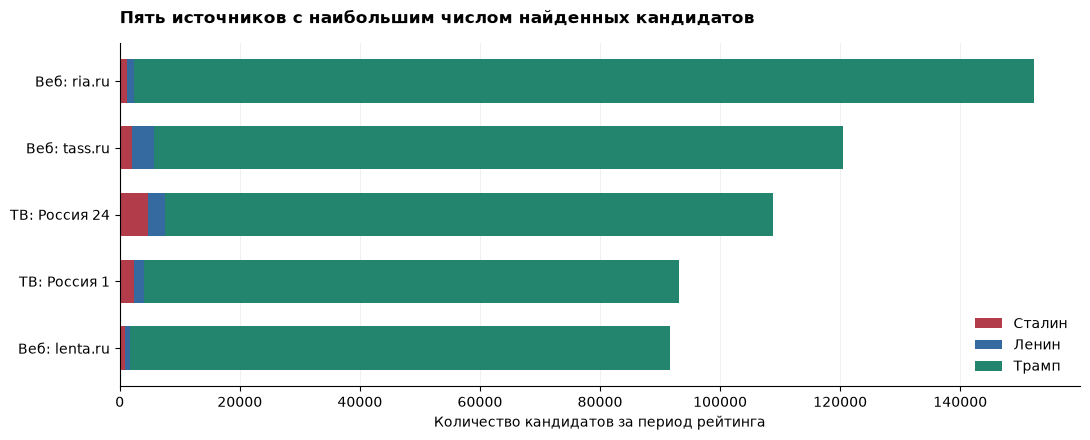

In [6]:
rank_data = daily.loc[daily['day'] <= RANK_END]
ranking = rank_data.groupby(['source','kind'])[COLS].sum(min_count=1).reset_index()
ranking['total_candidates'] = ranking[COLS].sum(axis=1,min_count=1)
ranking = ranking.sort_values(['total_candidates','source'],ascending=[False,True]).reset_index(drop=True)
eligible = ranking if TOP_SCOPE=='all' else ranking.loc[ranking['kind']==TOP_SCOPE]
top5 = eligible.head(TOP_N).copy()
TOP_SOURCES = top5['source'].tolist()
display(top5.rename(columns={**{c:PEOPLE[c.removesuffix('_candidates')] for c in COLS},
                            'source':'Источник','kind':'Тип','total_candidates':'Всего'}))
for kind,label in [('web','Веб-медиа'),('tv','ТВ-каналы')]:
    display(Markdown(f'**{label}**'))
    display(ranking.loc[ranking['kind']==kind].head(TOP_N))

fig, ax = plt.subplots(figsize=(11,4.5))
top5.set_index('source')[COLS].rename(columns={c:PEOPLE[c.removesuffix('_candidates')] for c in COLS}).iloc[::-1].plot.barh(
    stacked=True, color=list(COLORS.values()), ax=ax, width=.65)
ax.set_title('Пять источников с наибольшим числом найденных кандидатов', loc='left', pad=14)
ax.set_xlabel('Количество кандидатов за период рейтинга'); ax.set_ylabel('')
ax.grid(axis='x',alpha=.18); ax.set_axisbelow(True)
ax.legend(title=None,frameon=False)
fig.tight_layout(); fig.savefig(FIGURES/'top5_ranking.png',dpi=150,bbox_inches='tight')
plt.show(); plt.close(fig)


## 6. Функция построения графиков

В каждом рисунке три строки (день, неделя, месяц) и три столбца (Сталин, Ленин,
Трамп). Шкалы отдельных панелей различаются, чтобы редкие упоминания оставались
видны. Разрыв линии — отсутствие данных. Оранжевые точки — частичное покрытие
или неполный крайний период; для веб покрытие оценено косвенно. Если неполных
периодов много, их число указано на панели, а точками отмечены только крайние периоды.


In [7]:
def plot_series(frame, title, filename):
    fig, axes = plt.subplots(3,3,figsize=(16,10.5))
    for i,(key,(freq,label)) in enumerate(PERIODS.items()):
        series = aggregate(frame,freq).sort_values('day')
        for j,(person,name) in enumerate(PEOPLE.items()):
            ax = axes[i,j]; values = series[f'{person}_candidates']
            ax.plot(series['day'],values,color=COLORS[person],lw=.9 if key=='day' else 1.5)
            flagged = series['partial'] & values.notna()
            dense_flags = flagged.sum() > .2 * len(series)
            marked = (~series['calendar_complete'] & values.notna()) if dense_flags else flagged
            ax.scatter(series.loc[marked,'day'],values.loc[marked],s=10,
                       facecolors='none',edgecolors='#c98828',linewidths=.6,zorder=3)
            if dense_flags:
                ax.text(.98,.94,f'Неполных периодов: {flagged.sum()}/{len(series)}',
                        transform=ax.transAxes,ha='right',va='top',fontsize=8,color='#777777',
                        bbox={'facecolor':'white','edgecolor':'none','alpha':.85})
            ax.set_title(f'{name} · {label.lower()}',loc='left',fontsize=11)
            ax.set_ylim(bottom=0); ax.grid(alpha=.18); ax.set_axisbelow(True)
            locator = mdates.AutoDateLocator(minticks=3,maxticks=6)
            ax.xaxis.set_major_locator(locator)
            ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
            ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f'{v:,.0f}'.replace(',',' ')))
            if j==0: ax.set_ylabel('Кандидаты на упоминания')
    fig.suptitle(title,fontsize=17,x=.07,ha='left',y=.98)
    fig.text(.07,.944,f'{START:%d.%m.%Y}–{END:%d.%m.%Y} · даты Москвы · недельные и месячные значения — суммы',fontsize=10,color='#555555')
    fig.text(.07,.02,'Разрывы: нет данных. Оранжевые точки: неполные периоды. Веб-покрытие оценено косвенно; фамилии не проверены по контексту.',fontsize=9,color='#555555')
    fig.tight_layout(rect=(.01,.05,1,.925),h_pad=2,w_pad=2)
    fig.savefig(FIGURES/filename,dpi=150,bbox_inches='tight')
    plt.show(); plt.close(fig)

def combined_daily(kind):
    group = daily.loc[daily['kind']==kind].groupby('day')
    counts = group[COLS].sum(min_count=1)
    # Сумма наблюдаемой части корпуса. Неполнота хотя бы одного источника отмечается.
    result = counts.join(group.agg(observed=('observed','any'),complete_day=('complete_day','all'))).reset_index()
    result['source'] = 'Все источники'; result['kind'] = kind
    return result


## 7. Общая динамика: ТВ и веб отдельно


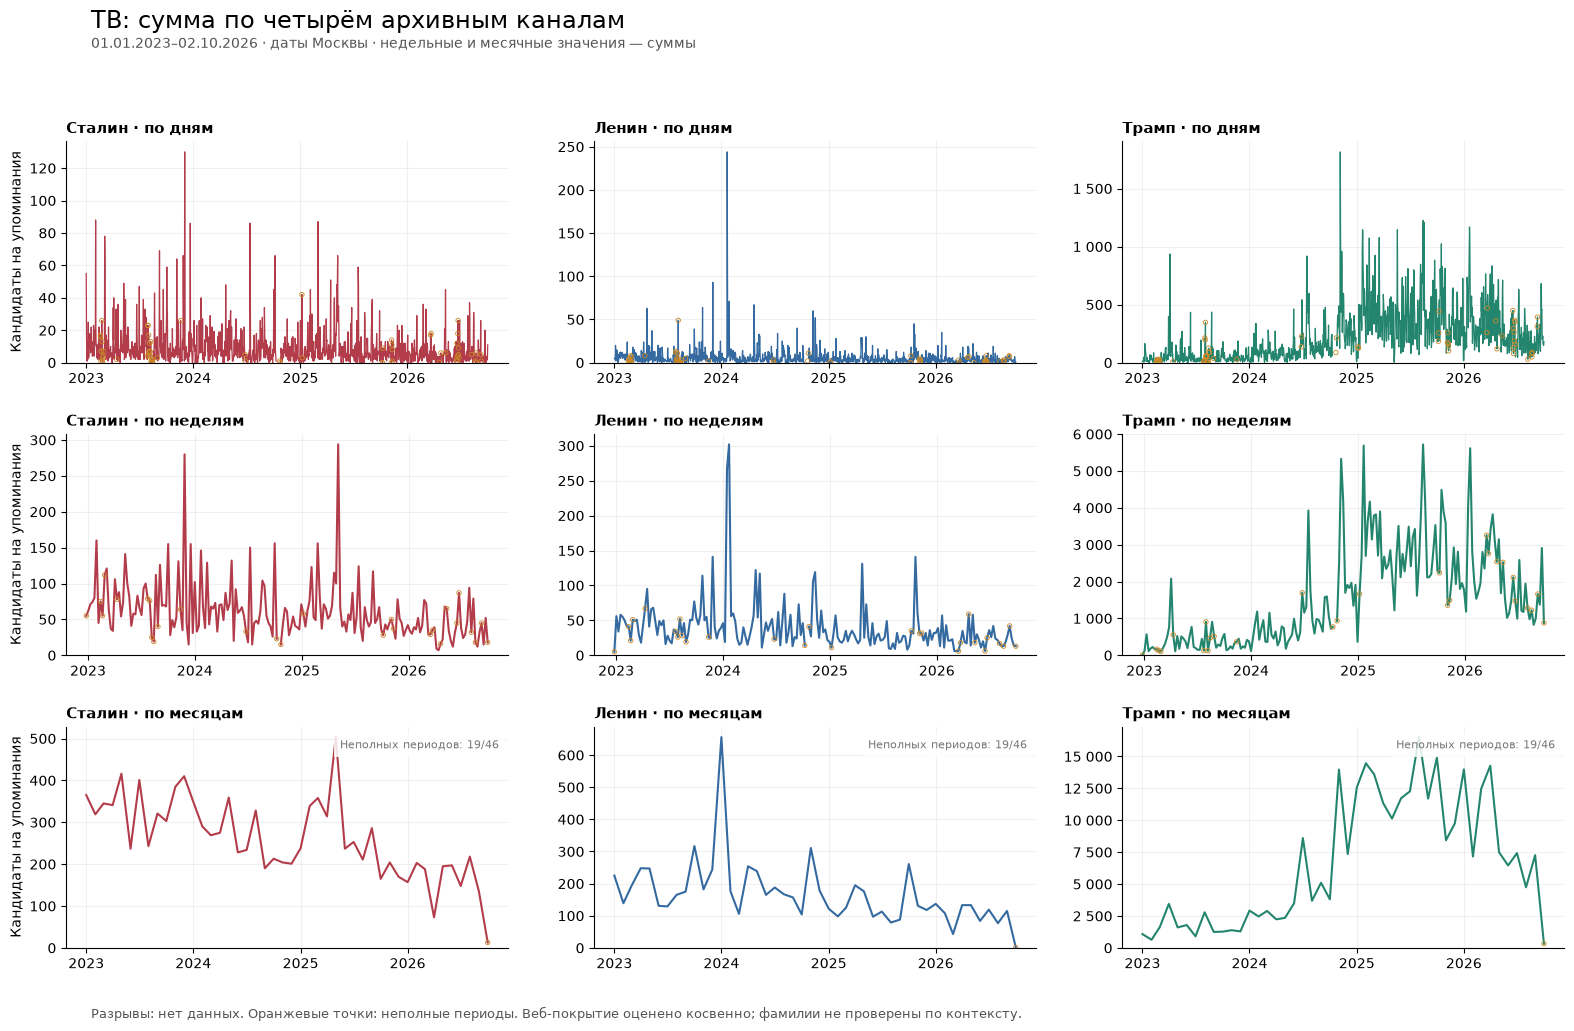

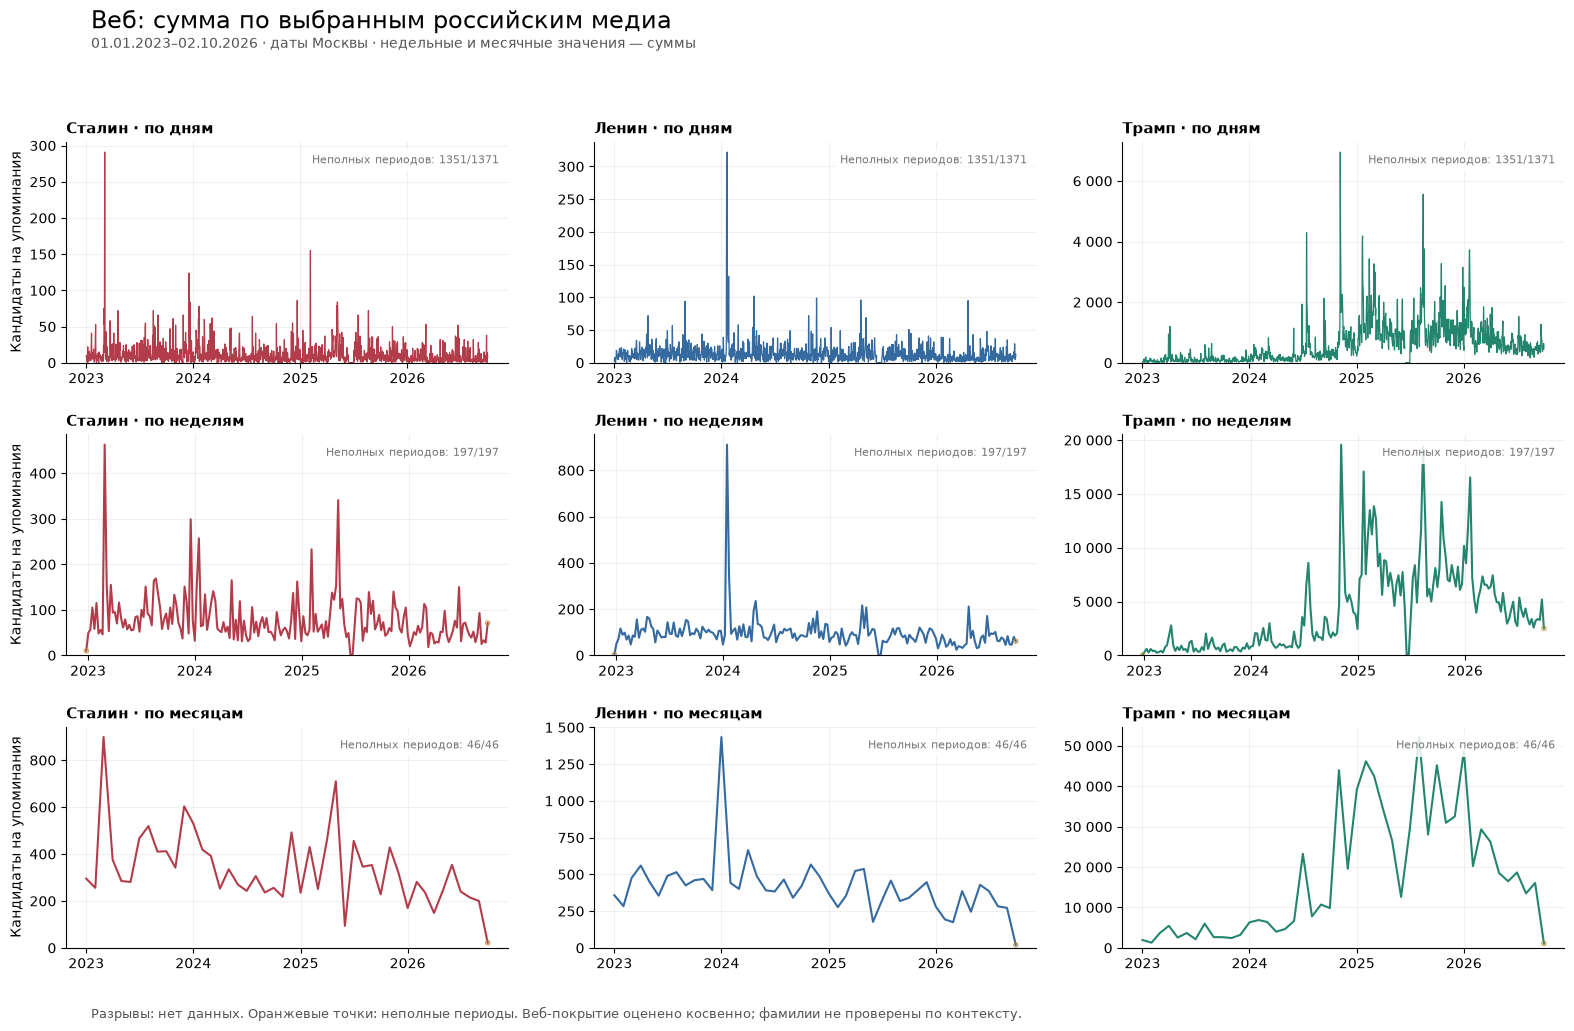

In [8]:
plot_series(combined_daily('tv'),'ТВ: сумма по четырём архивным каналам','overview_tv.png')
plot_series(combined_daily('web'),'Веб: сумма по выбранным российским медиа','overview_web.png')


## 8. Отдельный рисунок для каждого из пяти источников


### 1. Веб: ria.ru

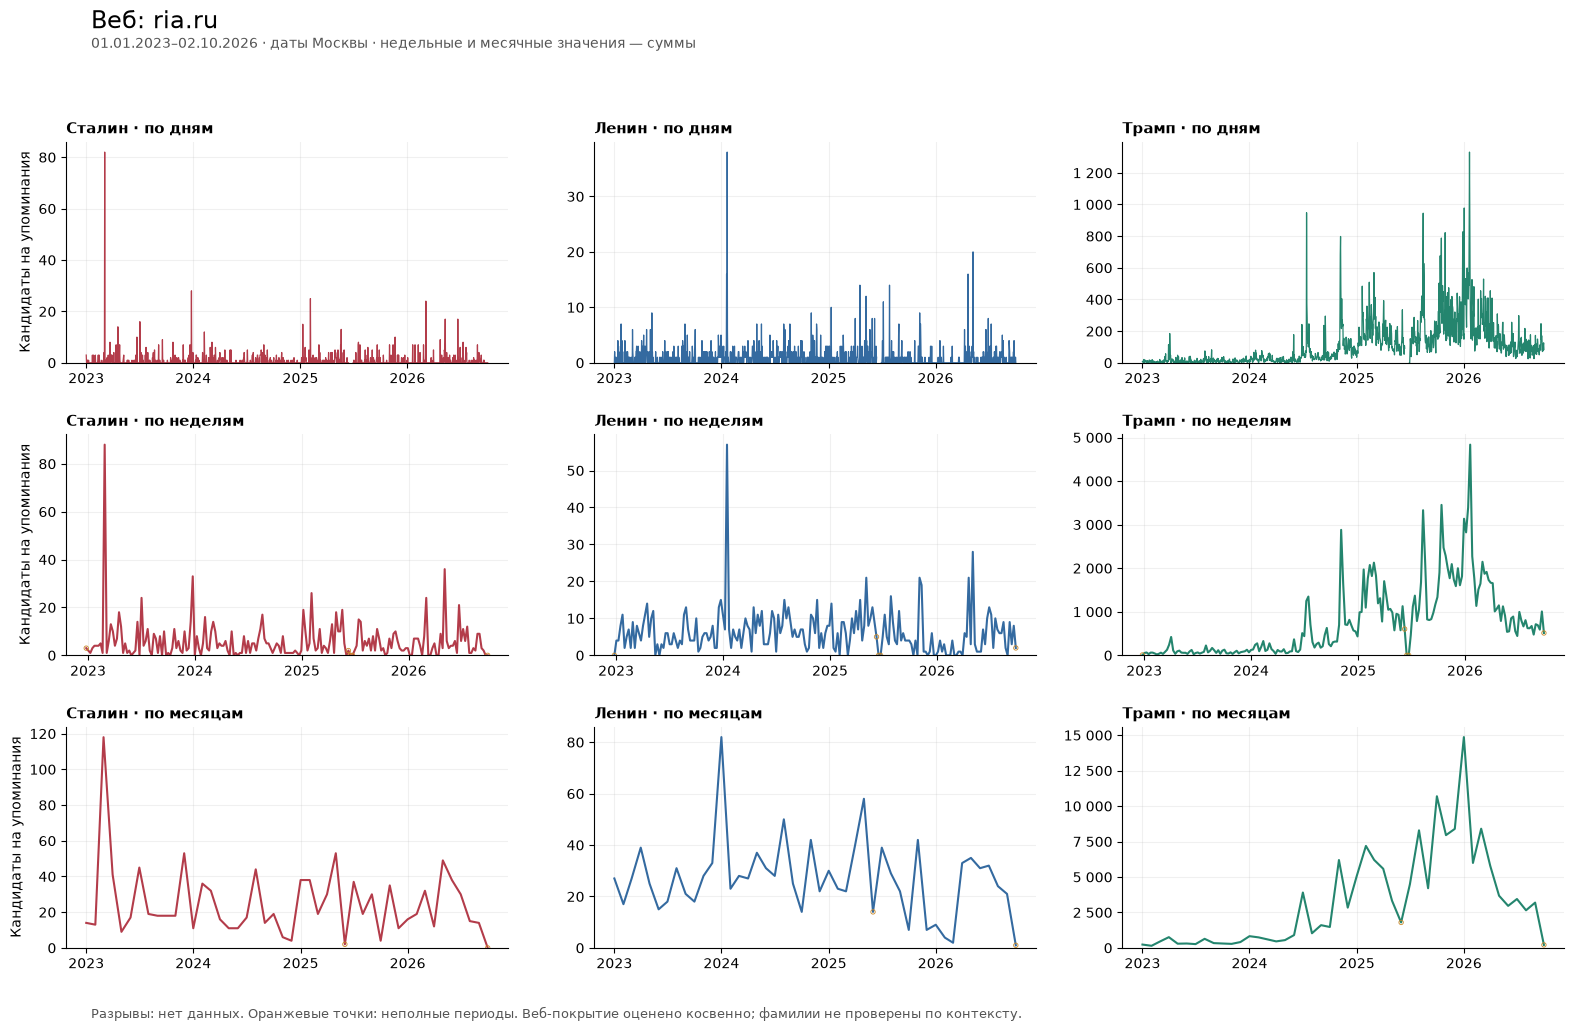

### 2. Веб: tass.ru

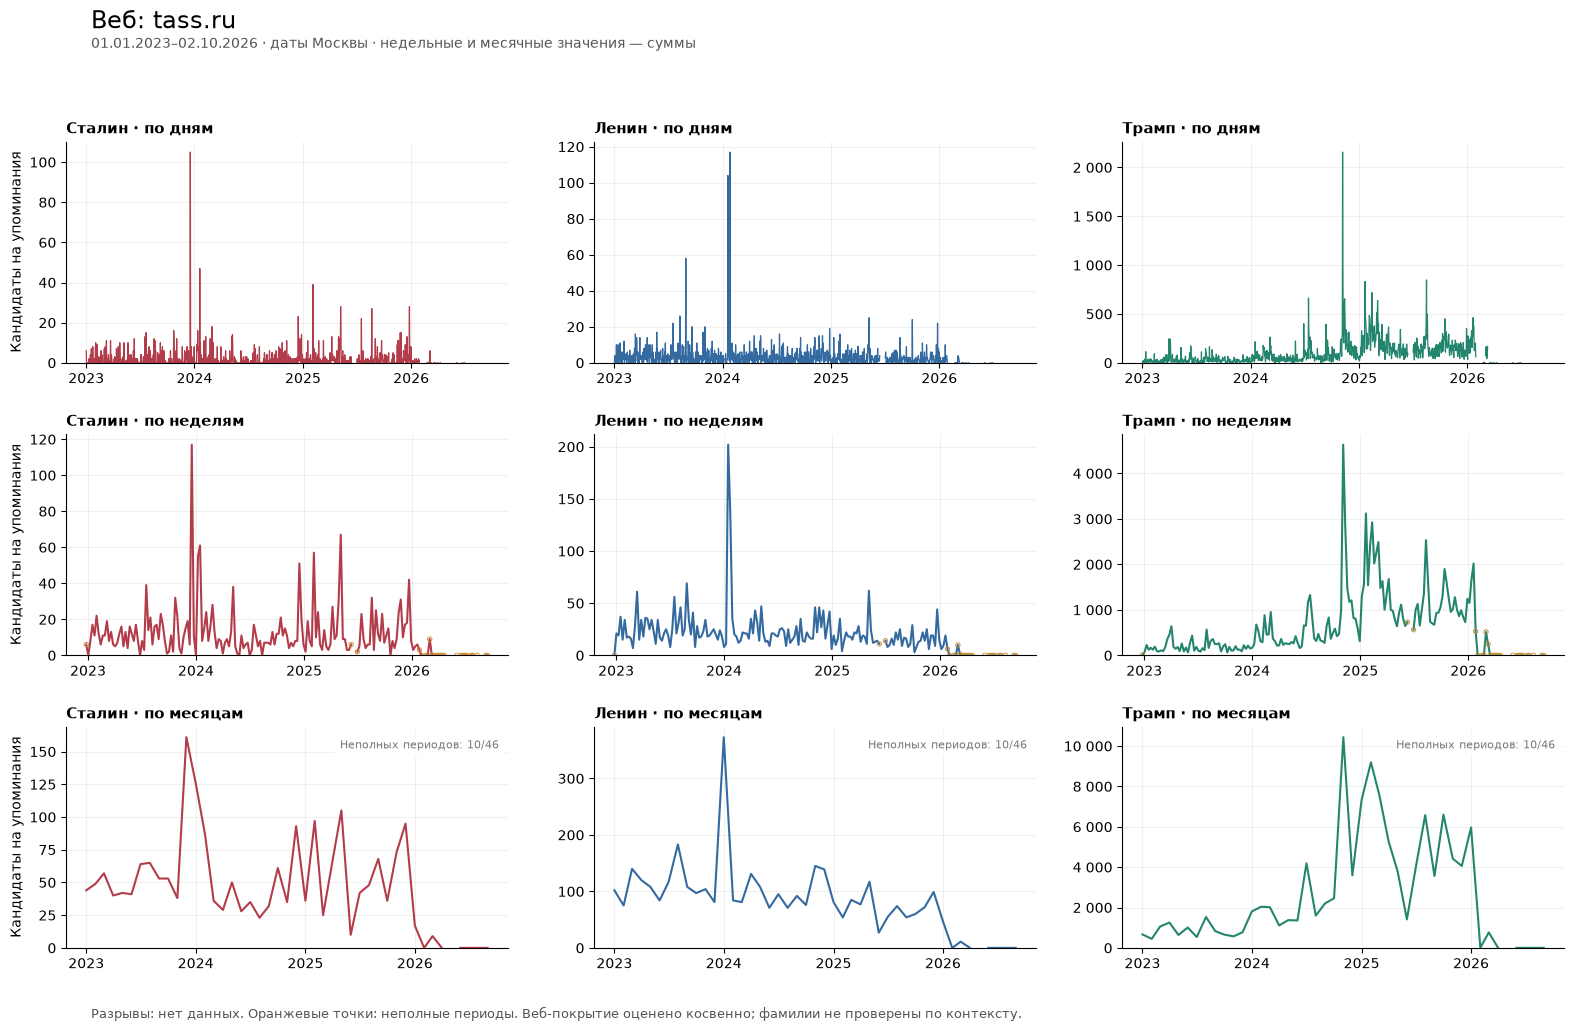

### 3. ТВ: Россия 24

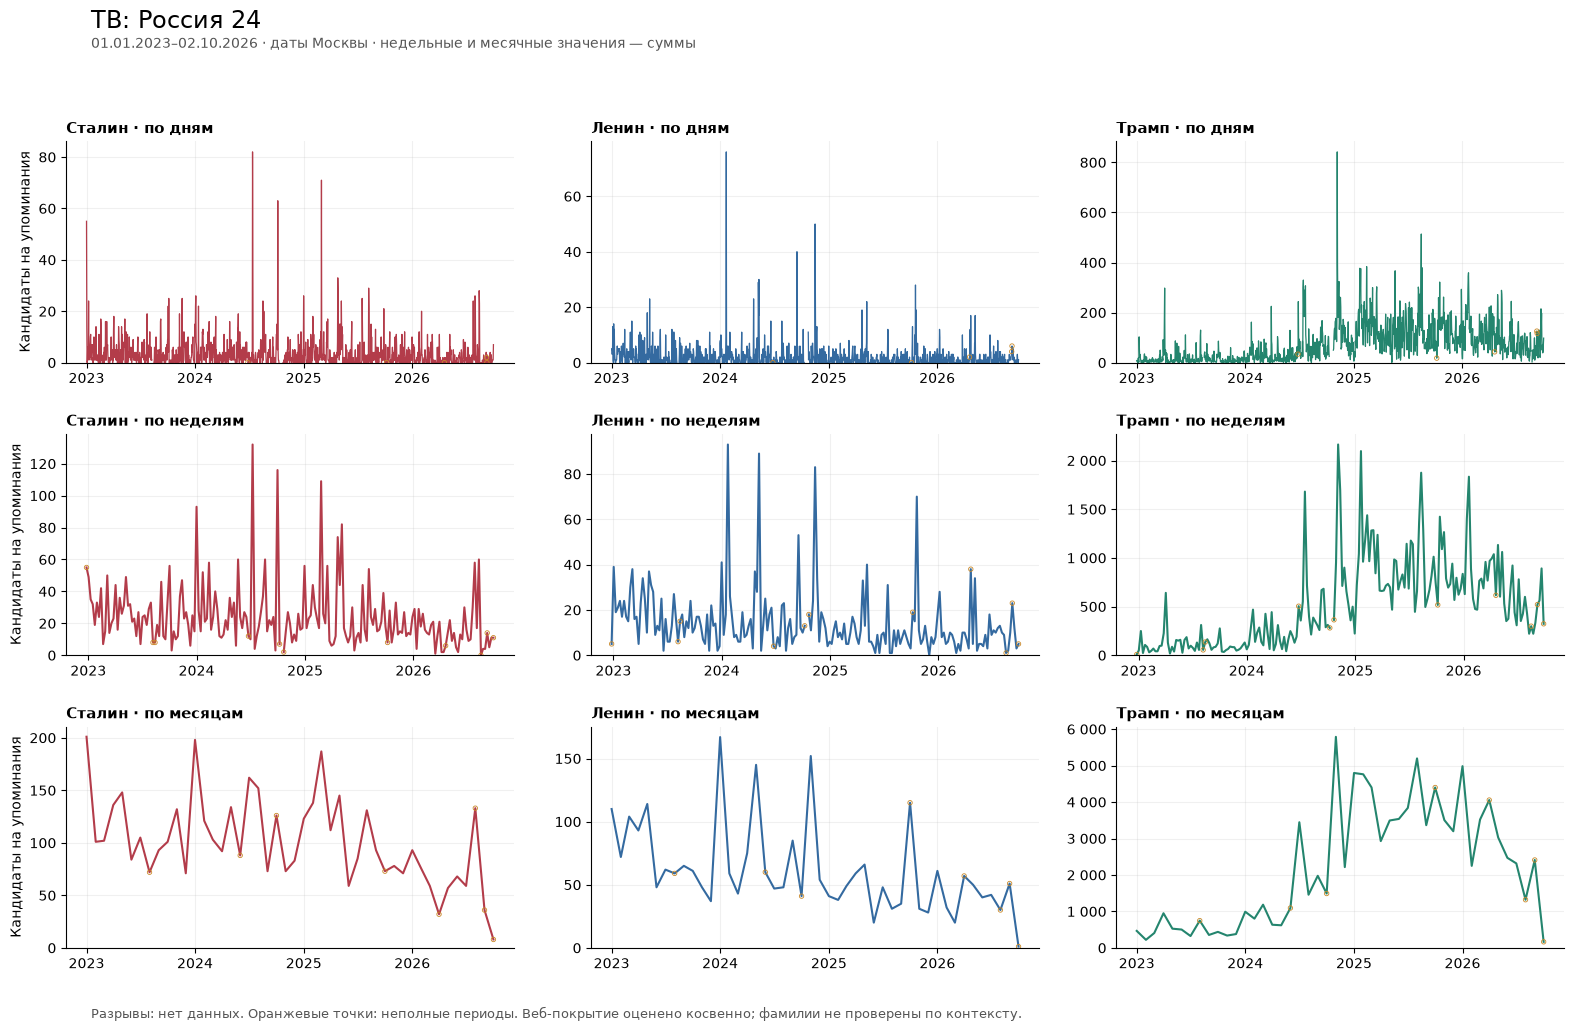

### 4. ТВ: Россия 1

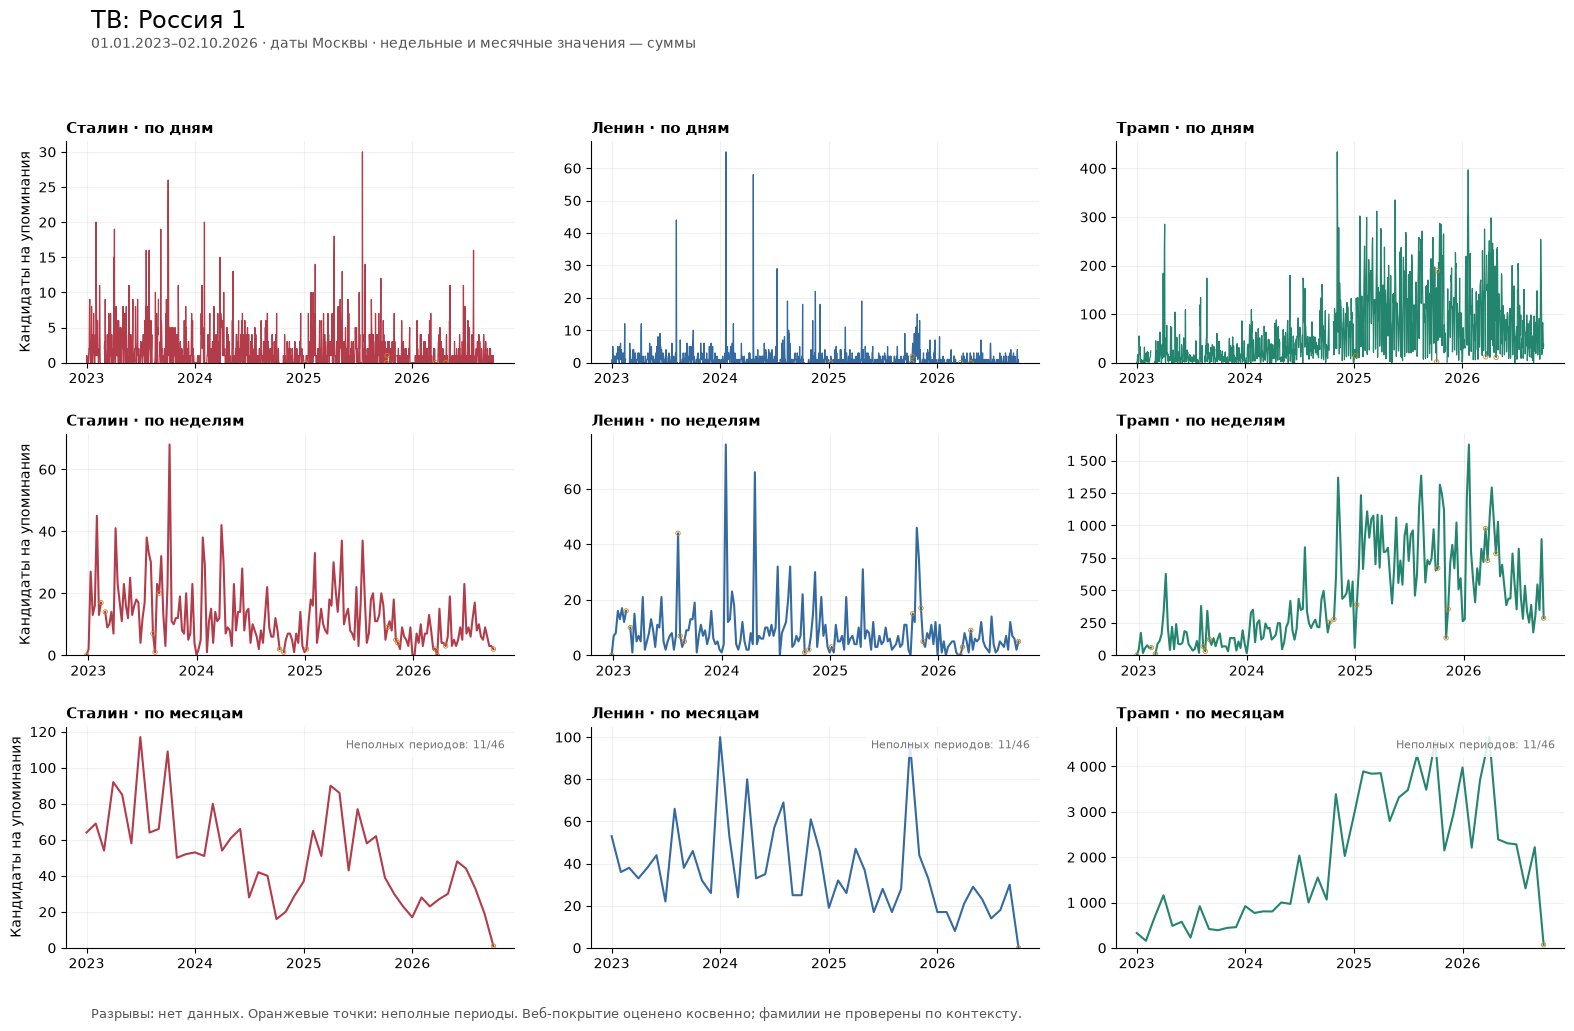

### 5. Веб: lenta.ru

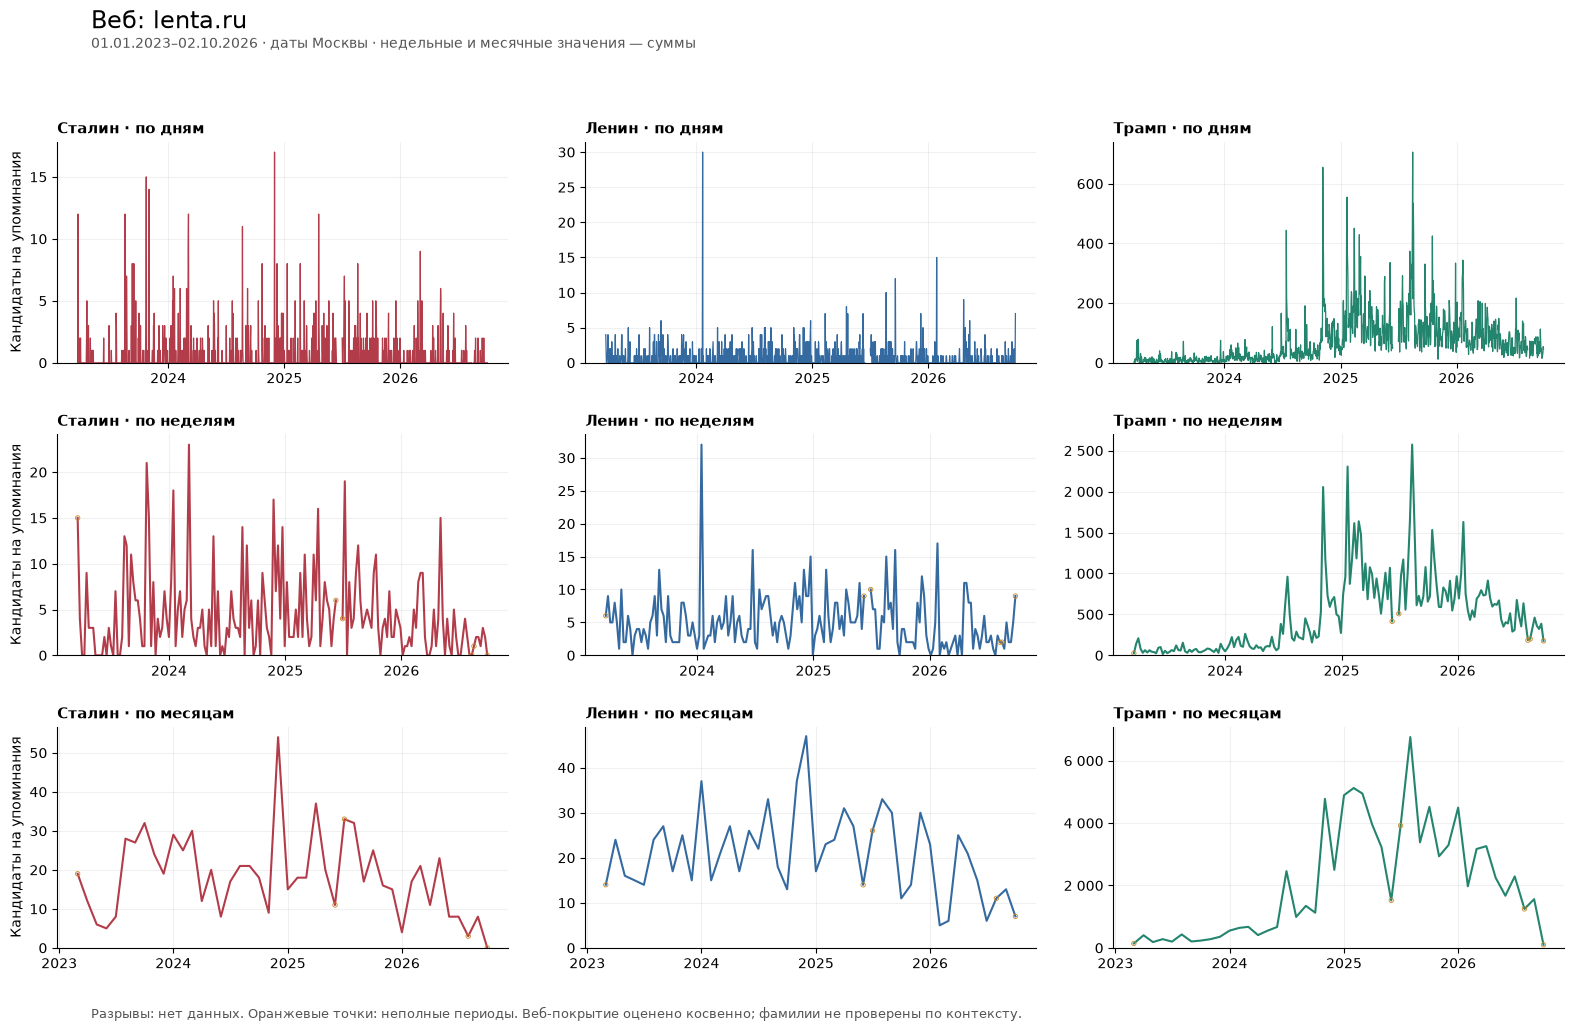

In [9]:
for rank,source in enumerate(TOP_SOURCES,1):
    display(Markdown(f'### {rank}. {source}'))
    frame = daily.loc[daily['source']==source]
    plot_series(frame,source,f'top{rank:02d}_source.png')


## 9. Сохранение рядов и результата проверки

Таблицы по всем источникам сохраняются в сжатом виде вместе с флагами покрытия.
Для прогнозирования не заполняйте пропуски нулями автоматически; неполные дни и
месяцы требуют отдельного решения. Последний месяц октябрь 2026 нельзя сравнивать
по сумме с полным сентябрём без учёта числа наблюдённых дней.


In [10]:
for key,panel in panels.items():
    panel.to_csv(TABLES/f'mentions_{key}.csv.gz',index=False,compression='gzip')
ranking.to_csv(TABLES/'source_ranking.csv',index=False,encoding='utf-8-sig')
coverage.to_csv(TABLES/'coverage.csv',encoding='utf-8-sig')
report = {'start_day':str(START.date()),'end_day':str(END.date()),'timezone':'Europe/Moscow',
          'top_scope':TOP_SCOPE,'rank_end':str(RANK_END.date()),'top_sources':TOP_SOURCES,
          'web_daily_rows':len(web),'tv_daily_rows':len(tv),'sources':daily['source'].nunique(),
          'totals_conserved_for_day_week_month':True,'missing_days_preserved':True,
          'web_definition':'All candidate rows in earliest observed candidate-containing URL snapshot; pos is a decile and is not a deduplication key',
          'person_disambiguation':'not_done','news_program_filter':'not_done',
          'tv_candidate_totals':dict(zip(PEOPLE,map(int,tv_panel[COLS].sum())))}
(ROOT/'audit/visualization_validation.json').write_text(json.dumps(report,ensure_ascii=False,indent=2),encoding='utf-8')
display(Markdown(f'Готово. **Графики:** `{FIGURES}`. **Таблицы:** `{TABLES}`.'))


Готово. **Графики:** `C:\Users\user\Documents\afgan\forecasting_mentions\output\mentions_visualization\figures`. **Таблицы:** `C:\Users\user\Documents\afgan\forecasting_mentions\output\mentions_visualization\tables`.